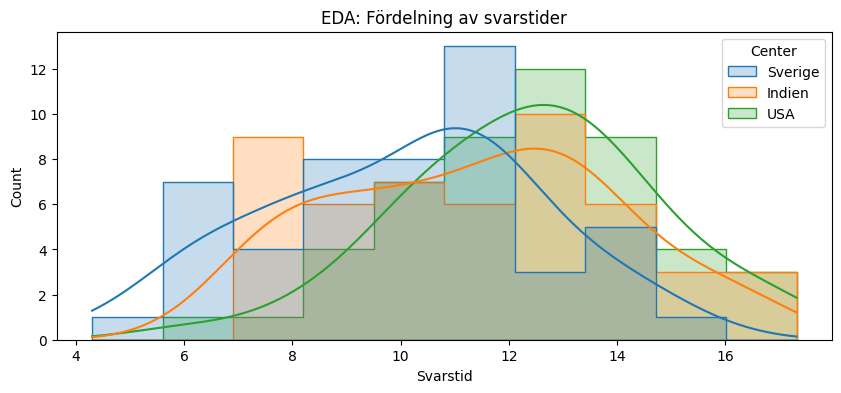

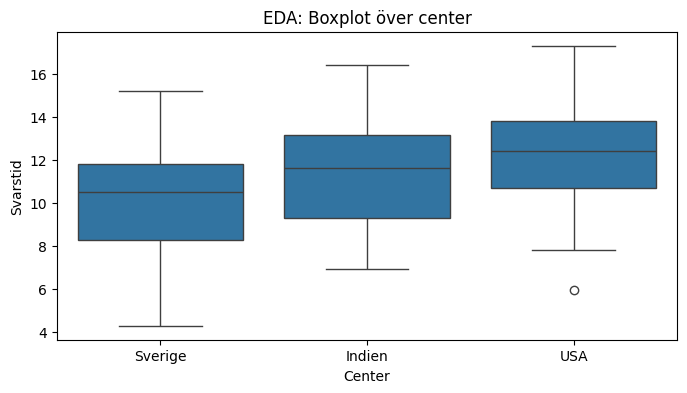

Normalitetskontroll (p > 0.05 betyder normalfördelad):
Sverige: p-värde = 0.5714
Indien: p-värde = 0.1272
USA: p-värde = 0.9855

ANOVA resultat: F=10.9211, p-värde=0.0000

Signifikant skillnad hittad! Genomför Tukey HSD:
 Multiple Comparison of Means - Tukey HSD, FWER=0.05  
 group1  group2 meandiff p-adj   lower   upper  reject
------------------------------------------------------
 Indien Sverige  -1.3384 0.0236 -2.5304 -0.1464   True
 Indien     USA   1.0067 0.1159 -0.1853  2.1987  False
Sverige     USA   2.3451    0.0  1.1531  3.5371   True
------------------------------------------------------


In [2]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# --- 1. Datagenerering (Grupp 15) ---
gruppnummer = 15
rng = np.random.default_rng(gruppnummer)
center = ['Sverige', 'Indien', 'USA']
n_per_group = 50
dist_type = "normal" # Grupp 15 är udda = normalfördelad

data_list = []
for i, c in enumerate(center):
    loc = 10 + (gruppnummer % 3) + i
    values = rng.normal(loc=loc, scale=2.5, size=n_per_group)
    temp_df = pd.DataFrame({'Center': c, 'Svarstid': values})
    data_list.append(temp_df)

df = pd.concat(data_list).reset_index(drop=True)

# --- 2. Explorativ Dataanalys (EDA) ---
plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='Svarstid', hue='Center', kde=True, element="step")
plt.title("EDA: Fördelning av svarstider")
plt.show()

plt.figure(figsize=(8, 4))
sns.boxplot(data=df, x='Center', y='Svarstid')
plt.title("EDA: Boxplot över center")
plt.show()

# --- 3. Test av antaganden (Shapiro-Wilk) ---
print("Normalitetskontroll (p > 0.05 betyder normalfördelad):")
for c in center:
    p_val_shapiro = stats.shapiro(df[df['Center'] == c]['Svarstid'])[1]
    print(f"{c}: p-värde = {p_val_shapiro:.4f}")

# --- 4. Hypotesprövning (ANOVA) ---
# H0: Ingen skillnad mellan centren. Ha: Det finns en skillnad.
groups = [df[df['Center'] == c]['Svarstid'] for c in center]
f_stat, p_val_anova = stats.f_oneway(*groups)
print(f"\nANOVA resultat: F={f_stat:.4f}, p-värde={p_val_anova:.4f}")

# --- 5. Post-hoc (Tukey) ---
if p_val_anova < 0.05:
    print("\nSignifikant skillnad hittad! Genomför Tukey HSD:")
    print(pairwise_tukeyhsd(df['Svarstid'], df['Center']))

Chi2-statistik: 170.6917, p-värde: 0.0000


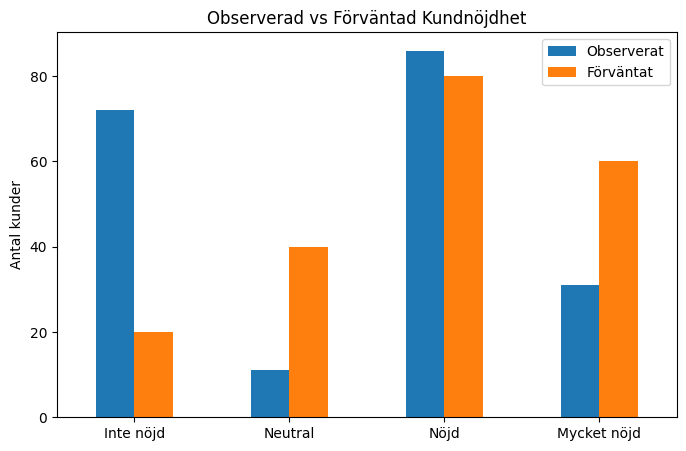

In [3]:
# --- 1. Generera data --- [cite: 131-150]
kategorier = ['Inte nöjd', 'Neutral', 'Nöjd', 'Mycket nöjd']
p_expected_pct = [0.10, 0.20, 0.40, 0.30]
offset = (gruppnummer % 105) * 0.02
p_group = [max(0.05, 0.10 + offset), max(0.05, 0.20 - offset), 0.40, 0.0]
p_group[3] = 1.0 - sum(p_group[:3])

antal_svar = 200
kundsvar = rng.choice(kategorier, size=antal_svar, p=p_group)
obs_counts = pd.Series(kundsvar).value_counts().reindex(kategorier, fill_value=0)

# --- 2. Beräkna förväntade frekvenser --- [cite: 155]
exp_counts = [p * antal_svar for p in p_expected_pct]

# --- 3. Chi2-test --- [cite: 152-156]
chi2_stat, p_val_chi2 = stats.chisquare(f_obs=obs_counts, f_exp=exp_counts)
print(f"Chi2-statistik: {chi2_stat:.4f}, p-värde: {p_val_chi2:.4f}")

# --- 4. Visualisering --- [cite: 159]
obs_exp_df = pd.DataFrame({'Observerat': obs_counts, 'Förväntat': exp_counts})
obs_exp_df.plot(kind='bar', figsize=(8, 5))
plt.title("Observerad vs Förväntad Kundnöjdhet")
plt.ylabel("Antal kunder")
plt.xticks(rotation=0)
plt.show()

In [7]:
# --- Uppgift 10: Fishers exakta test ---

# 1. Definiera sannolikheter för Grupp 15 [cite: 185]
ai_rate = 0.7 + (gruppnummer % 4) * 0.05
man_rate = 0.4 + (gruppnummer % 3) * 0.05

# 2. Simulera utfall för 12 patienter per grupp [cite: 186]
ai_results = rng.binomial(n=1, p=ai_rate, size=12)
man_results = rng.binomial(n=1, p=man_rate, size=12)

# 3. Räkna korrekta vs felaktiga diagnoser [cite: 187-193]
ai_korrekt = np.sum(ai_results)
ai_fel = 12 - ai_korrekt
manual_korrekt = np.sum(man_results)
manual_fel = 12 - manual_korrekt

# 4. Skapa kontingenstabellen manuellt för testet [cite: 195-196]
tabell_matris = [[ai_korrekt, ai_fel],
                 [manual_korrekt, manual_fel]]

# 5. Skapa en Pandas DataFrame för snygg utskrift [cite: 197-199]
df_resultat = pd.DataFrame(tabell_matris,
                           index=['AI-verktyg', 'Manuell metod'],
                           columns=['Korrekt diagnos', 'Felaktig diagnos'])

# --- UTSKRIFT ---
print(f"--- Resultat för Grupp {gruppnummer} ---")
print("\nKontingenstabell:")
display(df_resultat) # 'display' gör att tabellen ser snygg ut i Jupyter

# 6. Genomför det statistiska testet [cite: 212-214]
odds_ratio, p_val_fisher = stats.fisher_exact(tabell_matris)

print(f"\nStatistisk analys:")
print(f"Odds-ratio: {odds_ratio:.4f}")
print(f"p-värde: {p_val_fisher:.4f}")

# 7. Kort tolkning för redovisningen [cite: 228-230]
if p_val_fisher < 0.05:
    print("\nSlutsats: Skillnaden är statistiskt signifikant (p < 0.05).")
else:
    print("\nSlutsats: Skillnaden är inte statistiskt signifikant (p >= 0.05).")

--- Resultat för Grupp 15 ---

Kontingenstabell:


,Korrekt diagnos,Felaktig diagnos
AI-verktyg,10,2
Manuell metod,6,6



Statistisk analys:
Odds-ratio: 5.0000
p-värde: 0.1930

Slutsats: Skillnaden är inte statistiskt signifikant (p >= 0.05).
